In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

In [2]:
# 1. Data Preprocessing
(x_train, y_train), (x_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
# Normalize images
x_train = x_train / 255.0
x_test = x_test / 255.0

In [4]:
# One-hot encode labels
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

In [5]:
model = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [7]:
#  Compile the model
model.compile(
    optimizer='sgd',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [8]:
# Train the model
history = model.fit(
    x_train, y_train,
    validation_split=0.1,
    epochs=20,
    batch_size=32
)

Epoch 1/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.6740 - loss: 1.1595 - val_accuracy: 0.9207 - val_loss: 0.2821
Epoch 2/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9086 - loss: 0.3148 - val_accuracy: 0.9373 - val_loss: 0.2271
Epoch 3/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9259 - loss: 0.2571 - val_accuracy: 0.9458 - val_loss: 0.1939
Epoch 4/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9349 - loss: 0.2269 - val_accuracy: 0.9522 - val_loss: 0.1730
Epoch 5/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9433 - loss: 0.1961 - val_accuracy: 0.9605 - val_loss: 0.1518
Epoch 6/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9515 - loss: 0.1698 - val_accuracy: 0.9645 - val_loss: 0.1380
Epoch 7/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9538 - loss: 0.1576 - val_accuracy: 0.9655 - val_loss: 0.1284
Epoch 8/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9557 - loss: 0.1511 

In [9]:
# Evaluate the model
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"\nTest accuracy: {test_acc:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9687 - loss: 0.1038

Test accuracy: 0.9725


In [12]:
#  Predict on a single image
def predict_single_image(index):
    img = x_test[index]
    plt.imshow(img, cmap='gray')
    plt.show()

    img = np.expand_dims(img, axis=0)  # reshape to (1, 28, 28)
    prediction = model.predict(img)
    predicted_label = np.argmax(prediction)
    print(f"Predicted Label: {predicted_label}")

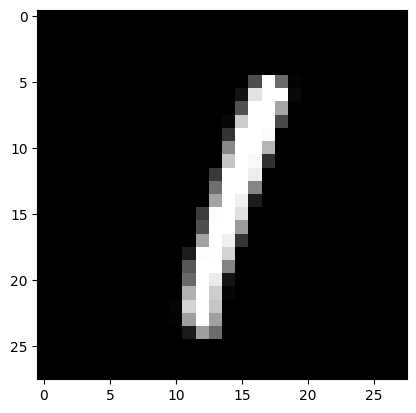

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
Predicted Label: 1


In [13]:
predict_single_image(5)